In [10]:
# Setup

%load_ext autoreload
%autoreload 2
#%load_ext jupyter_ai_magics
import sys; sys.path.append('..')
from src.env_setup import init_analysis_env; init_analysis_env()

df_ = load_local_data("Stock Screener Data*.csv*", na_values=['-'], dtype={'Code': str})
df_.head()

# Cleaning

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
🚀 Analysis environment initialized: pd, np, yf, plt, sns, load_local_data, ai, datetime, timedelta, xw are ready.
Loading: /home/mrsmmori/notebooks/Win_Downloads/Stock Screener Data 7 Jun 11-8-22.csv.csv


,Trading Name,Code,Last Price,ROE %,Mkt Cap ($M),Tot. Rev ($M),P/E,Yield (%),Sector,GTI Score,4-wk %Pr. Chg.,13-wk %Pr. Chg.,26-wk %Pr. Chg.,52-wk %Pr. Chg.,Net Profit,Price/CF,Debt/Equity,1-yr %Rev. Chg.,Price/Book Value
0,Tai Sin Electric,500,0.55,12.09,SGD 250.843,SGD 527.837,14.30,4.31,Industrials,78.00,-5.22,5.24,-5.56,38.66,0.05,NaN,0.04,19.98,1.12
1,HS Optimus,504,0.01,5.73,SGD 37.664,SGD 13.551,13.73,NaN,Consumer Cyclical,67.00,0.00,133.33,250.00,250.00,0.20,74.07,0.01,-6.18,0.77
2,AsiaMedic,505,0.02,13.34,SGD 26.4,SGD 35.221,13.14,NaN,Healthcare,66.00,0.00,21.05,21.05,91.67,0.03,6.85,0.96,21.81,1.64
3,Fuji Offset,508,0.73,2.33,SGD 43.736,SGD 3.274,48.34,0.68,Industrials,70.00,28.95,5.76,36.11,-10.91,0.28,357.14,0.00,-9.76,1.14
4,DISA,532,0.00,-137.72,SGD 14.09,SGD 2.667,NaN,NaN,Technology,34.00,0.00,0.00,0.00,0.00,-0.42,NaN,0.01,-19.20,3.67


In [11]:
df = df_.copy()

In [12]:
rename_dict = {
    'Trading Name':    'name',
    'Code':            'code',
    'Last Price':      'price',
    'ROE %':           'roe',
    'Mkt Cap ($M)':    'mkt_cap',
    'Tot. Rev ($M)':   'rev',
    'P/E':             'pe',
    'Yield (%)':       'yield',
    'Sector':          'sector',
    'GTI Score':       'gti',
    '4-wk %Pr. Chg.':  'chg_4w',
    '13-wk %Pr. Chg.': 'chg_13w',
    '26-wk %Pr. Chg.': 'chg_26w',
    '52-wk %Pr. Chg.': 'chg_52w',
    'Net Profit':      'net_profit',
    'Price/CF':        'p_cf',
    'Debt/Equity':     'de',
    '1-yr %Rev. Chg.': 'rev_chg_1y',
    'Price/Book Value':'pb'
}

df = df.rename(columns=rename_dict)

In [13]:
df['mkt_cap'] = pd.to_numeric(df['mkt_cap'], errors='coerce')
df['mkt_cap'] = df['mkt_cap'].fillna(0)
cap_cutoff = df['mkt_cap'].quantile(0.30)  # 下位30%の足切りライン
df = df[df['mkt_cap'] >= cap_cutoff]
df

,name,code,price,roe,mkt_cap,rev,pe,yield,sector,gti,chg_4w,chg_13w,chg_26w,chg_52w,net_profit,p_cf,de,rev_chg_1y,pb
0,Tai Sin Electric,500,0.55,12.09,0.00,SGD 527.837,14.30,4.31,Industrials,78.00,-5.22,5.24,-5.56,38.66,0.05,NaN,0.04,19.98,1.12
1,HS Optimus,504,0.01,5.73,0.00,SGD 13.551,13.73,NaN,Consumer Cyclical,67.00,0.00,133.33,250.00,250.00,0.20,74.07,0.01,-6.18,0.77
2,AsiaMedic,505,0.02,13.34,0.00,SGD 35.221,13.14,NaN,Healthcare,66.00,0.00,21.05,21.05,91.67,0.03,6.85,0.96,21.81,1.64
3,Fuji Offset,508,0.73,2.33,0.00,SGD 3.274,48.34,0.68,Industrials,70.00,28.95,5.76,36.11,-10.91,0.28,357.14,0.00,-9.76,1.14
4,DISA,532,0.00,-137.72,0.00,SGD 2.667,NaN,NaN,Technology,34.00,0.00,0.00,0.00,0.00,-0.42,NaN,0.01,-19.20,3.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,Zheneng Jinjiang,BWM,0.58,9.24,0.00,"SGD 3,784.87",6.13,6.32,Utilities,68.90,6.32,5.42,35.22,36.70,0.20,2.91,0.95,1.44,0.55
611,Zhongmin Baihui,5SR,0.42,20.54,0.00,SGD 960.396,14.77,2.38,Consumer Cyclical,74.90,-6.67,-17.65,-9.68,-24.56,0.03,3.44,0.97,-3.30,1.87
612,Zhongxin Fruit,5EG,0.03,19.54,0.00,SGD 165.24,8.58,NaN,Consumer Defensive,68.50,-5.71,-5.71,-13.16,3.13,0.12,26.60,NaN,76.44,1.02
613,ZICO Hldgs,40W,0.05,3.83,0.00,SGD 14.276,NaN,2.04,Industrials,76.30,16.67,-28.57,8.70,19.05,-0.47,NaN,0.03,2.06,0.72


In [14]:
df['rev'].sort_values()

608     CNY 28,504.82
517       EUR 214.617
278        EUR 50.434
173        GBP 38.305
532    HKD 12,044.085
            ...      
351               NaN
450               NaN
455               NaN
456               NaN
560               NaN
Name: rev, Length: 615, dtype: str

In [15]:
fx_rates = {
    'SGD': 1.0,
    'GBP': 1.70,
    'USD': 1.35,  # 1 USD = 1.35 SGD
    'EUR': 1.45,  # 1 EUR = 1.45 SGD
    'CNY': 0.19,  # 1 CNY = 0.19 SGD
    'HKD': 0.17,  # 1 HKD = 0.17 SGD
    'MYR': 0.29,  # 1 MYR = 0.29 SGD
}

def convert_rev_to_sgd(row_value):
    val_str = str(row_value).strip().upper()
    if val_str in ['NAN', 'NONE', '-', '']:
        return 0.0
    
    detected_currency = 'SGD'
    

    for curr in fx_rates.keys():
        if curr in val_str:
            detected_currency = curr
            val_str = val_str.replace(curr, '') 
            break
            

    val_str = val_str.replace(',', '').strip()
    try:
        num_val = float(val_str)
    except ValueError:
        return 0.0
        

    return num_val * fx_rates[detected_currency]

df['rev_sgd'] = df['rev'].apply(convert_rev_to_sgd)

df_top5 = df.sort_values(by='rev_sgd', ascending=False).groupby('sector').head(5)

df_top5 = df_top5.sort_values(by=['sector', 'rev_sgd'], ascending=[True, False])

result_cols = ['sector', 'name', 'code', 'rev', 'rev_sgd', 'mkt_cap']
df_top5[result_cols]

,sector,name,code,rev,rev_sgd,mkt_cap
322,Basic Materials,Le Tree Holdings,E6R,"SGD 283,025",283025.00,0.00
509,Basic Materials,Sri Trang Agro,NC2,"SGD 105,934.507",105934.51,0.00
510,Basic Materials,Sri Trang Gloves,STG,"SGD 22,829.589",22829.59,0.00
133,Basic Materials,ChinaSunsine,QES,"SGD 3,277.392",3277.39,0.00
230,Basic Materials,Halcyon Agri,5VJ,"SGD 2,961.538",2961.54,0.00
...,...,...,...,...,...,...
483,Utilities,SIIC Environment,BHK,"SGD 7,072.781",7072.78,0.00
468,Utilities,Sembcorp Ind,U96,"SGD 5,799",5799.00,0.00
126,Utilities,China Everbright,U9E,"SGD 5,355.11",5355.11,0.00
610,Utilities,Zheneng Jinjiang,BWM,"SGD 3,784.87",3784.87,0.00


<class 'pandas.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        615 non-null    str    
 1   code        615 non-null    str    
 2   price       615 non-null    float64
 3   roe         564 non-null    str    
 4   mkt_cap     615 non-null    float64
 5   rev         605 non-null    str    
 6   pe          369 non-null    float64
 7   yield       334 non-null    float64
 8   sector      605 non-null    str    
 9   gti         537 non-null    float64
 10  chg_4w      603 non-null    float64
 11  chg_13w     601 non-null    float64
 12  chg_26w     597 non-null    float64
 13  chg_52w     583 non-null    str    
 14  net_profit  587 non-null    float64
 15  p_cf        429 non-null    float64
 16  de          522 non-null    float64
 17  rev_chg_1y  585 non-null    str    
 18  pb          575 non-null    float64
 19  rev_sgd     615 non-null    float64
dtyp

,price,mkt_cap,pe,yield,gti,chg_4w,chg_13w,chg_26w,net_profit,p_cf,de,pb,rev_sgd
count,615.00,615.00,369.00,334.00,537.00,603.00,601.00,597.00,587.00,429.00,522.00,575.00,615.00
mean,1.39,0.00,26.56,4.93,71.02,-0.70,6.94,13.81,-1.51,18.34,0.63,2.82,72614.92
std,5.66,0.00,56.76,13.84,15.68,23.22,37.02,69.97,18.01,48.99,2.35,11.47,1170969.07
min,0.00,0.00,0.10,0.11,15.50,-82.60,-82.60,-79.33,-380.00,0.30,0.00,0.03,-3.26
25%,0.05,0.00,8.76,1.81,62.00,-6.82,-5.41,-8.82,-0.04,3.91,0.04,0.53,20.98
50%,0.21,0.00,13.54,3.22,71.50,-1.83,0.00,0.00,0.03,7.79,0.19,0.90,100.19
75%,0.77,0.00,23.26,5.12,80.30,0.76,7.14,14.96,0.12,14.86,0.58,1.84,440.77
max,79.97,0.00,660.00,239.17,114.10,290.32,384.00,858.33,5.93,714.29,45.84,192.31,21056904.00


<class 'pandas.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        615 non-null    str    
 1   code        615 non-null    str    
 2   price       615 non-null    float64
 3   roe         564 non-null    str    
 4   mkt_cap     615 non-null    float64
 5   rev         605 non-null    str    
 6   pe          369 non-null    float64
 7   yield       334 non-null    float64
 8   sector      605 non-null    str    
 9   gti         537 non-null    float64
 10  chg_4w      603 non-null    float64
 11  chg_13w     601 non-null    float64
 12  chg_26w     597 non-null    float64
 13  chg_52w     583 non-null    str    
 14  net_profit  587 non-null    float64
 15  p_cf        429 non-null    float64
 16  de          522 non-null    float64
 17  rev_chg_1y  585 non-null    str    
 18  pb          575 non-null    float64
 19  rev_sgd     615 non-null    float64
dtyp

,price,mkt_cap,pe,yield,gti,chg_4w,chg_13w,chg_26w,net_profit,p_cf,de,pb,rev_sgd
count,615.00,615.00,369.00,334.00,537.00,603.00,601.00,597.00,587.00,429.00,522.00,575.00,615.00
mean,1.39,0.00,26.56,4.93,71.02,-0.70,6.94,13.81,-1.51,18.34,0.63,2.82,72614.92
std,5.66,0.00,56.76,13.84,15.68,23.22,37.02,69.97,18.01,48.99,2.35,11.47,1170969.07
min,0.00,0.00,0.10,0.11,15.50,-82.60,-82.60,-79.33,-380.00,0.30,0.00,0.03,-3.26
25%,0.05,0.00,8.76,1.81,62.00,-6.82,-5.41,-8.82,-0.04,3.91,0.04,0.53,20.98
50%,0.21,0.00,13.54,3.22,71.50,-1.83,0.00,0.00,0.03,7.79,0.19,0.90,100.19
75%,0.77,0.00,23.26,5.12,80.30,0.76,7.14,14.96,0.12,14.86,0.58,1.84,440.77
max,79.97,0.00,660.00,239.17,114.10,290.32,384.00,858.33,5.93,714.29,45.84,192.31,21056904.00


<class 'pandas.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        615 non-null    str    
 1   code        615 non-null    str    
 2   price       615 non-null    float64
 3   roe         564 non-null    str    
 4   mkt_cap     615 non-null    float64
 5   rev         605 non-null    str    
 6   pe          369 non-null    float64
 7   yield       334 non-null    float64
 8   sector      605 non-null    str    
 9   gti         537 non-null    float64
 10  chg_4w      603 non-null    float64
 11  chg_13w     601 non-null    float64
 12  chg_26w     597 non-null    float64
 13  chg_52w     583 non-null    str    
 14  net_profit  587 non-null    float64
 15  p_cf        429 non-null    float64
 16  de          522 non-null    float64
 17  rev_chg_1y  585 non-null    str    
 18  pb          575 non-null    float64
 19  rev_sgd     615 non-null    float64
dtyp

...

<Axes: xlabel='mkt_cap', ylabel='sector'>

Text(0.5, 1.0, 'セクター別の総時価総額 (SGD)')

Text(0.5, 0, '総時価総額')

Text(0, 0.5, 'セクター')

/tmp/ipykernel_128624/2634681194.py:14: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:14: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:14: UserWarning: Glyph 20385 (\N{CJK UNIFIED IDEOGRAPH-4FA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:14: UserWarning: Glyph 38989 (\N{CJK UNIFIED IDEOGRAPH-984D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:14: UserWarning: Glyph 12475 (\N{KATAKANA LETTER SE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:14: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:14: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing 

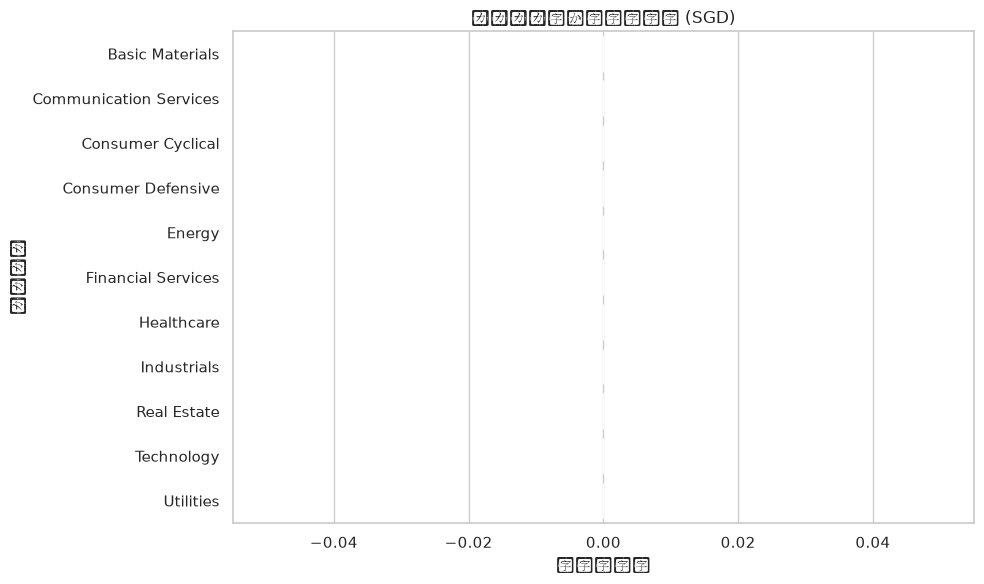

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='rev_sgd', ylabel='mkt_cap'>

Text(0.5, 1.0, '売上高 vs 時価総額の相関')

Text(0.5, 0, '売上高 (SGD)')

Text(0, 0.5, '時価総額')

/tmp/ipykernel_128624/2634681194.py:24: UserWarning: Glyph 22770 (\N{CJK UNIFIED IDEOGRAPH-58F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:24: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:24: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:24: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:24: UserWarning: Glyph 20385 (\N{CJK UNIFIED IDEOGRAPH-4FA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:24: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:24: UserWarning: Glyph 38989 (\N{CJK UNIFIED I

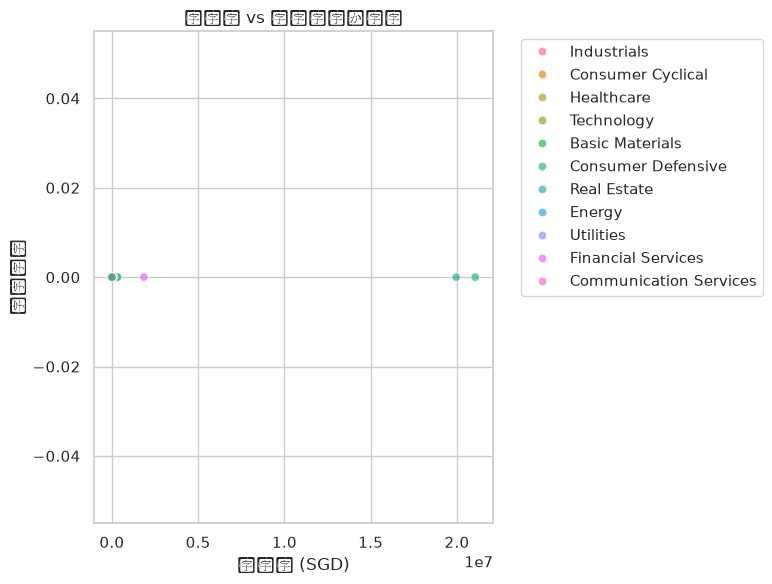

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='mkt_cap', ylabel='sector'>

Text(0.5, 1.0, 'セクター別の総時価総額 (SGD)')

Text(0.5, 0, '総時価総額')

Text(0, 0.5, 'セクター')

/tmp/ipykernel_128624/2634681194.py:14: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:14: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:14: UserWarning: Glyph 20385 (\N{CJK UNIFIED IDEOGRAPH-4FA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:14: UserWarning: Glyph 38989 (\N{CJK UNIFIED IDEOGRAPH-984D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:14: UserWarning: Glyph 12475 (\N{KATAKANA LETTER SE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:14: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:14: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing 

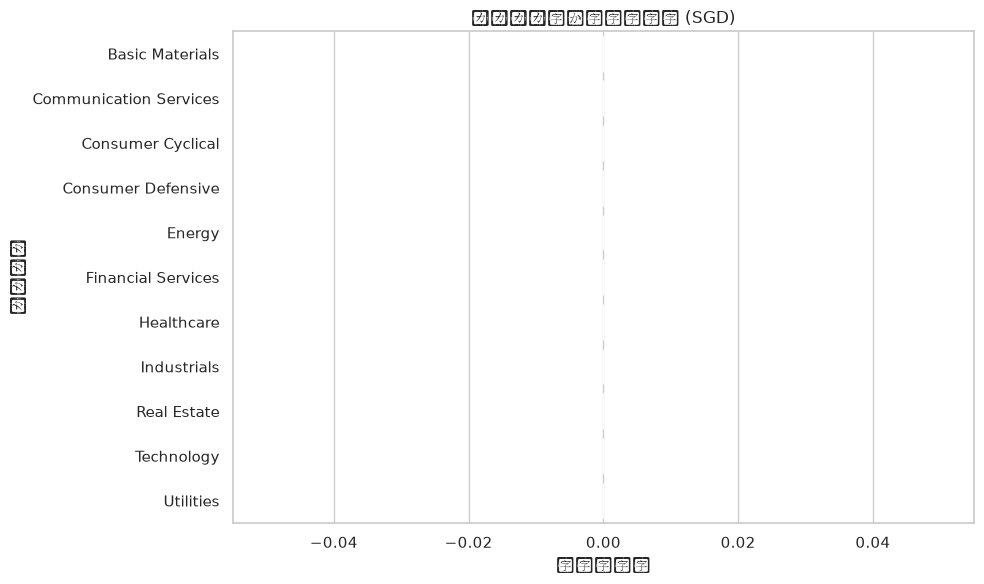

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='rev_sgd', ylabel='mkt_cap'>

Text(0.5, 1.0, '売上高 vs 時価総額の相関')

Text(0.5, 0, '売上高 (SGD)')

Text(0, 0.5, '時価総額')

/tmp/ipykernel_128624/2634681194.py:24: UserWarning: Glyph 22770 (\N{CJK UNIFIED IDEOGRAPH-58F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:24: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:24: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:24: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:24: UserWarning: Glyph 20385 (\N{CJK UNIFIED IDEOGRAPH-4FA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:24: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128624/2634681194.py:24: UserWarning: Glyph 38989 (\N{CJK UNIFIED I

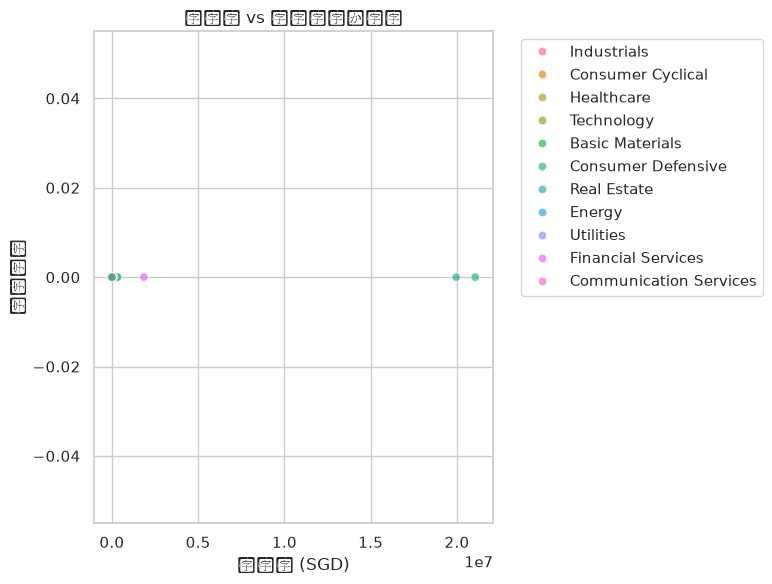

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter Labで日本語やグラフを綺麗に表示するための設定
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif' # 環境に合わせて変更してください

# ① セクターごとの時価総額の総計を棒グラフにする
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='mkt_cap', y='sector', estimator=sum, errorbar=None, order=df.groupby('sector')['mkt_cap'].sum().sort_values(ascending=False).index)
plt.title('セクター別の総時価総額 (SGD)')
plt.xlabel('総時価総額')
plt.ylabel('セクター')
plt.tight_layout()
plt.show()

# ② 売上高（rev_sgd）と時価総額（mkt_cap）の相関を散布図にする
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='rev_sgd', y='mkt_cap', hue='sector', alpha=0.7)
plt.title('売上高 vs 時価総額の相関')
plt.xlabel('売上高 (SGD)')
plt.ylabel('時価総額')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()